<p>در این بخش سه مدل

RGB

YCbCr

HSV

انتخاب و اعمال شدند</p>

In [2]:
import numpy as np
from imageio import imread, imwrite
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import uniform_filter1d

img = np.rot90(imread("myimg.jpg"), -1)
imwrite("original_color.jpg", img)

r, g, b = img[..., 0], img[..., 1], img[..., 2]

zeros = np.zeros_like(r)

img_r = np.stack([r, zeros, zeros], axis=2)
img_g = np.stack([zeros, g, zeros], axis=2)
img_b = np.stack([zeros, zeros, b], axis=2)

imwrite("channel_R_color.jpg", img_r.astype(np.uint8))
imwrite("channel_G_color.jpg", img_g.astype(np.uint8))
imwrite("channel_B_color.jpg", img_b.astype(np.uint8))





<ipython-input-2-5936357d7579>:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = np.rot90(imread("myimg.jpg"), -1)


In [3]:
def normalize_img(img):
    return np.clip(img * 255, 0, 255).astype(np.uint8)

def rgb_to_hsv(image):
    img = image / 255.0
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    cmax = np.max(img, axis=2)
    cmin = np.min(img, axis=2)
    delta = cmax - cmin

    hue = np.zeros_like(cmax)
    mask = delta != 0
    hue[mask & (cmax == r)] = (60 * ((g - b) / delta) % 360)[mask & (cmax == r)]
    hue[mask & (cmax == g)] = (60 * ((b - r) / delta + 2))[mask & (cmax == g)]
    hue[mask & (cmax == b)] = (60 * ((r - g) / delta + 4))[mask & (cmax == b)]
    hue /= 360

    saturation = np.zeros_like(cmax)
    saturation[cmax != 0] = (delta / cmax)[cmax != 0]

    value = cmax

    hsv = np.stack([hue, saturation, value], axis=2)
    return hsv

hsv = rgb_to_hsv(img)

hue_img = normalize_img(hsv[:, :, 0])
sat_img = normalize_img(hsv[:, :, 1])
val_img = normalize_img(hsv[:, :, 2])

imwrite("hue.jpg", hue_img)
imwrite("saturation.jpg", sat_img)
imwrite("value.jpg", val_img)

<ipython-input-3-3eb6553b7f9e>:13: RuntimeWarning: invalid value encountered in divide
  hue[mask & (cmax == r)] = (60 * ((g - b) / delta) % 360)[mask & (cmax == r)]
<ipython-input-3-3eb6553b7f9e>:14: RuntimeWarning: invalid value encountered in divide
  hue[mask & (cmax == g)] = (60 * ((b - r) / delta + 2))[mask & (cmax == g)]
<ipython-input-3-3eb6553b7f9e>:15: RuntimeWarning: invalid value encountered in divide
  hue[mask & (cmax == b)] = (60 * ((r - g) / delta + 4))[mask & (cmax == b)]
<ipython-input-3-3eb6553b7f9e>:19: RuntimeWarning: invalid value encountered in divide
  saturation[cmax != 0] = (delta / cmax)[cmax != 0]


In [4]:
def rgb_to_ycbcr(image):
    img = image.astype(np.float32)
    y =  0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    cb = -0.168736 * img[:, :, 0] - 0.331264 * img[:, :, 1] + 0.5 * img[:, :, 2] + 128
    cr =  0.5 * img[:, :, 0] - 0.418688 * img[:, :, 1] - 0.081312 * img[:, :, 2] + 128

    ycbcr = np.stack([y, cb, cr], axis=2)
    return np.clip(ycbcr, 0, 255).astype(np.uint8)

ycbcr = rgb_to_ycbcr(img)

y_img = ycbcr[:, :, 0]
cb_img = ycbcr[:, :, 1]
cr_img = ycbcr[:, :, 2]

imwrite("Y_channel.jpg", y_img)
imwrite("Cb_channel.jpg", cb_img)
imwrite("Cr_channel.jpg", cr_img)


<p>همانگونه که می‌بینیم هیستوگرام رنگ آبی خیلی پهن است پس کنتراست بیشتری دارد سبز و خاکستری کنتراستی کمتر و مشابه دارند و در آخر قرمز از همه کنتراست کمتری دارد</p>

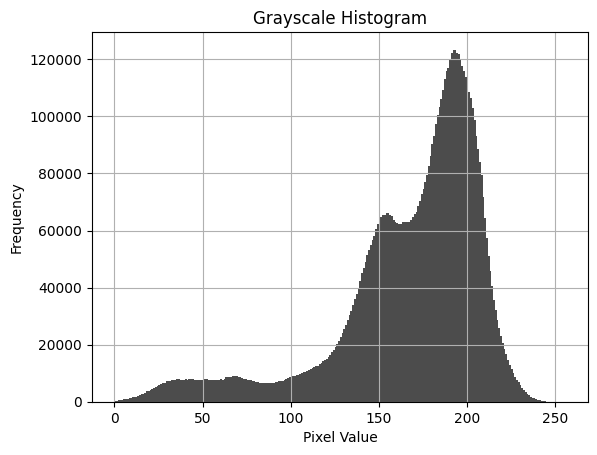

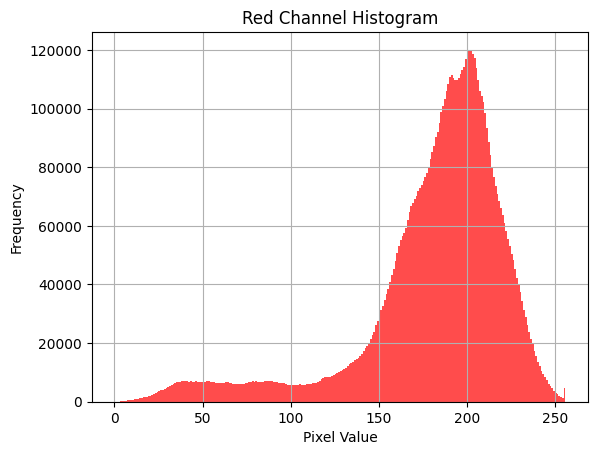

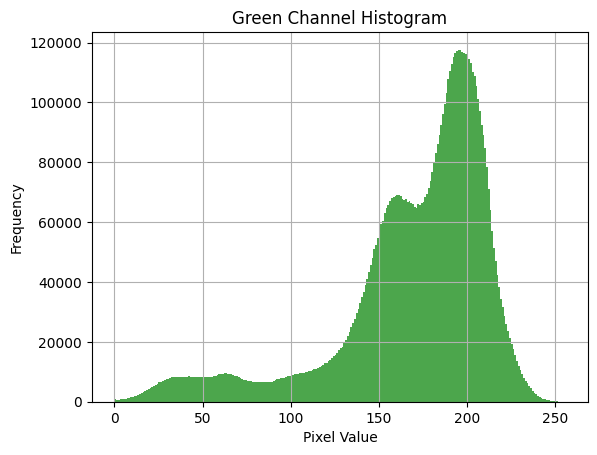

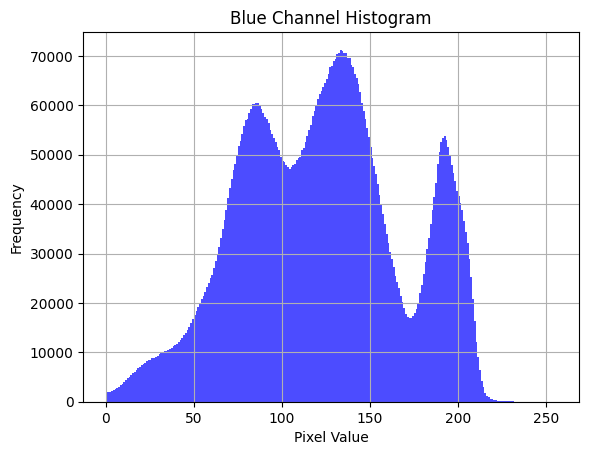

In [5]:
gray = np.dot(img[..., :3], [0.299, 0.587, 0.114])
gray = np.clip(gray, 0, 255).astype(np.uint8)
imwrite("gray.jpg", gray)

def plot_histogram(data, title, color='gray'):
    plt.figure()
    plt.hist(data.ravel(), bins=256, range=(0, 256), color=color, alpha=0.7)
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

plot_histogram(gray, "Grayscale Histogram", color='black')

plot_histogram(r, "Red Channel Histogram", color='red')
plot_histogram(g, "Green Channel Histogram", color='green')
plot_histogram(b, "Blue Channel Histogram", color='blue')


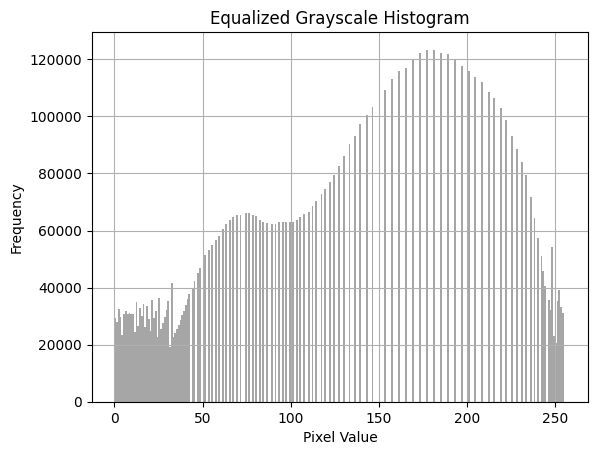

In [6]:
def histogram_equalization(img):
    hist, bins = np.histogram(img.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * 255 / cdf[-1]
    equalized = np.interp(img.flatten(), bins[:-1], cdf_normalized)
    return equalized.reshape(img.shape).astype(np.uint8)

gray_eq = histogram_equalization(gray)
imwrite("gray_equalized.jpg", gray_eq)
plot_histogram(gray_eq, "Equalized Grayscale Histogram", color='gray')


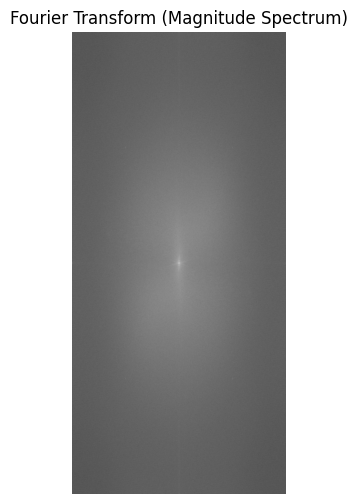

In [7]:
f_transform = fft2(gray)
f_shift = fftshift(f_transform)
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)  # log for visibility

plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Transform (Magnitude Spectrum)")
plt.axis('off')
plt.show()


<p>همانطور که می‌بینیم بیشتر پیکسل ها که مقداری بیشتر از 0 دارند در مرکز تصویر متمرکز شده‌اند</p>